## Simulation of Single-Qubit Gates using the Jaynes–Cummings Model

We simulate the dynamics of a two-level system (qubit) under the Jaynes–Cummings (JC) Hamiltonian to implement and analyze the performance of fundamental quantum gates: $X$, $Y$, $Z$, and Hadamard ($H$).

The JC Hamiltonian used is:

$
\hat{H}_{\text{JC}} = \hbar \omega_r \hat{a}^\dagger \hat{a} + \frac{1}{2} \hbar \omega_q \hat{\sigma}_z + \hbar g (\hat{a}^\dagger \hat{\sigma}_- + \hat{a} \hat{\sigma}_+)
$

where:
- $\omega_r$ is the resonator frequency,  
- $\omega_q$ is the qubit transition frequency,  
- $g$ is the coupling strength,  
- $\hat{a}^\dagger$, $\hat{a}$ are bosonic creation and annihilation operators,  
- $\hat{\sigma}_z$ is the Pauli-Z operator,  
- $\hat{\sigma}_\pm$ are the raising and lowering operators.

The qubit is driven using external cosine pulses shaped to implement the desired gates.




 ## X Gate

--- Starting Qubit Fidelity Analysis with Peak Detection ---

Part A: Calibrating to find optimal π-pulse time...
--> Optimal π-pulse (X-gate) time found: 12.480000 ns

Part B: Running high-resolution simulation for 43.68 ns to observe oscillations...
Main simulation complete.

Part C: Calculating QUBIT fidelity and finding peaks...
--> Found 9 significant peaks:
  - Peak 1: Time = 2.4889 ns, Fidelity = 0.9995
  - Peak 2: Time = 7.5289 ns, Fidelity = 0.9988
  - Peak 3: Time = 12.5067 ns, Fidelity = 0.9999
  - Peak 4: Time = 17.4844 ns, Fidelity = 0.9989
  - Peak 5: Time = 22.5244 ns, Fidelity = 0.9996
  - Peak 6: Time = 27.5022 ns, Fidelity = 0.9993
  - Peak 7: Time = 32.4800 ns, Fidelity = 0.9991
  - Peak 8: Time = 37.5200 ns, Fidelity = 0.9997
  - Peak 9: Time = 42.4978 ns, Fidelity = 0.9991


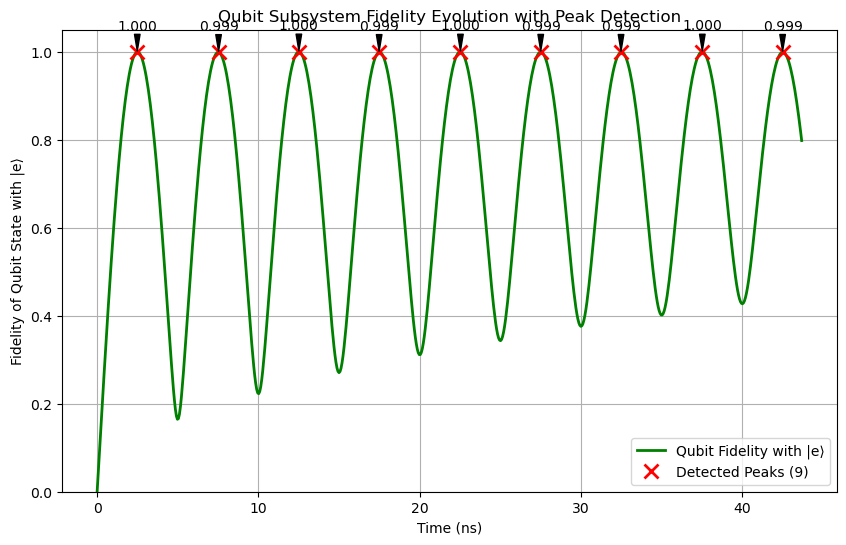


Part D: Generating Bloch sphere animation for the full evolution...


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from qutip import (
    tensor, qeye, destroy, basis, mesolve, sigmax, sigmay, sigmaz, sigmam, Bloch,
    fidelity
)
from scipy.signal import find_peaks
import time

# Use the older parameter name for compatibility with older matplotlib versions
try:
    plt.rcParams['animation.html_size_limit'] = 50.0
except KeyError:
    # Fallback for older versions
    plt.rcParams['animation.embed_limit'] = 50.0


# === Animation Class (Unchanged) ===
class BlochAnimation:
    def __init__(self, result, title, fig, axes):
        self.result, self.fig, self.axes = result, fig, axes
        self.sphere = Bloch(axes=axes); self.sphere.vector_color = ["r"]
        self.sphere.zlabel = [r'$|g\rangle$', r'$|e\rangle$']; self.sphere.title = title
    def update(self, n):
        self.sphere.clear()
        vec = [self.result.expect[0][n], self.result.expect[1][n], self.result.expect[2][n]]
        self.sphere.add_vectors(vec)
        self.sphere.add_points([self.result.expect[0][:n+1], self.result.expect[1][:n+1], self.result.expect[2][:n+1]], meth="l")
        self.sphere.make_sphere()
        return self.axes.artists


def plot_qubit_fidelity_and_animate_with_peaks():
    """
    This version finds and annotates the peaks in the qubit fidelity plot
    and runs the simulation long enough to generate multiple peaks.
    """
    print("--- Starting Qubit Fidelity Analysis with Peak Detection ---")
    
    # --- 1. SETUP: Parameters and Operators (Unchanged) ---
    wa = 5.0 * 2 * np.pi
    wc = 5.0 * 2 * np.pi
    g  = 0.1 * 2 * np.pi
    N  = 10
    Omega_d = 0.02 * 2 * np.pi
    omega_drive = wa
    gamma = 1.0 / 100e3
    kappa = 1.0 / 100

    a = tensor(destroy(N), qeye(2))
    sm = tensor(qeye(N), sigmam())
    H0 = wc * a.dag() * a + wa * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())
    H_drive_op = tensor(qeye(N), sigmax())
    drive_coeff = lambda t, args: 0.5 * Omega_d * np.cos(omega_drive * t)
    H_total = [H0, [H_drive_op, drive_coeff]]
    c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]
    rho_ground = tensor(basis(N, 0), basis(2, 0)) * tensor(basis(N, 0), basis(2, 0)).dag()

    # --- 2. CALIBRATION: Find the precise gate time (Unchanged) ---
    print("\nPart A: Calibrating to find optimal π-pulse time...")
    theoretical_gate_time = np.pi / Omega_d
    calibration_duration = theoretical_gate_time * 1.2
    tlist_calib = np.linspace(0, calibration_duration, 501)
    sz_operator = tensor(qeye(N), sigmaz())
    solver_options_calib = {"method": "bdf", "nsteps": 50000}
    
    result_calib = mesolve(H_total, rho_ground, tlist_calib, c_ops, [sz_operator], options=solver_options_calib)
    stop_index = np.argmin(result_calib.expect[0])
    precise_gate_time = tlist_calib[stop_index]
    print(f"--> Optimal π-pulse (X-gate) time found: {precise_gate_time:.6f} ns")

    # --- 3. MAIN SIMULATION ---
    simulation_duration = precise_gate_time * 3.5
    num_points = int(201 * 3.5) 
    print(f"\nPart B: Running high-resolution simulation for {simulation_duration:.2f} ns to observe oscillations...")
    
    tlist_main = np.linspace(0, simulation_duration, num_points)
    observables = [tensor(qeye(N), sigmax()), tensor(qeye(N), sigmay()), sz_operator]
    solver_options_main = {"method": "bdf", "nsteps": 50000, "store_states": True}
    
    result_main = mesolve(H_total, rho_ground, tlist_main, c_ops, observables, options=solver_options_main)
    print("Main simulation complete.")
    
    # --- 4. FIDELITY ANALYSIS AND PLOTTING WITH PEAK DETECTION ---
    print("\nPart C: Calculating QUBIT fidelity and finding peaks...")
    
    qubit_target_rho = basis(2, 1) * basis(2, 1).dag()
    fidelity_over_time = [
        fidelity(qubit_target_rho, state.ptrace(1)) for state in result_main.states
    ]

    # Find the peaks in the fidelity data
    peak_indices, _ = find_peaks(
        fidelity_over_time,
        height=0.5,
        prominence=0.2
    )
    
    # ***** THE FIX IS HERE *****
    # We must convert result_main.times to a numpy array before indexing with peak_indices.
    peak_times = np.array(result_main.times)[peak_indices]
    
    # This line was already correct, as it also converts the list to an array first.
    peak_fidelities = np.array(fidelity_over_time)[peak_indices]
    
    print(f"--> Found {len(peak_indices)} significant peaks:")
    for i in range(len(peak_times)):
        print(f"  - Peak {i+1}: Time = {peak_times[i]:.4f} ns, Fidelity = {peak_fidelities[i]:.4f}")

    # Plot the fidelity vs. time with peaks annotated
    fig_f, ax_f = plt.subplots(figsize=(10, 6))
    ax_f.plot(result_main.times, fidelity_over_time, lw=2, color='green', label='Qubit Fidelity with |e⟩')
    ax_f.plot(peak_times, peak_fidelities, "x", color='red', markersize=10, mew=2, label=f'Detected Peaks ({len(peak_indices)})')

    for i in range(len(peak_times)):
        ax_f.annotate(f'{peak_fidelities[i]:.3f}',
                      xy=(peak_times[i], peak_fidelities[i]),
                      xytext=(peak_times[i], peak_fidelities[i] + 0.05),
                      ha='center',
                      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    ax_f.set_xlabel("Time (ns)")
    ax_f.set_ylabel("Fidelity of Qubit State with |e⟩")
    ax_f.set_title("Qubit Subsystem Fidelity Evolution with Peak Detection")
    ax_f.set_ylim(0, 1.05)
    ax_f.grid(True)
    ax_f.legend()
    plt.show()

    # --- 5. ANIMATION ---
    print("\nPart D: Generating Bloch sphere animation for the full evolution...")
    

# Run the full analysis
if __name__ == '__main__':
    plot_qubit_fidelity_and_animate_with_peaks()

--- Starting Qubit Fidelity Analysis with Peak Detection ---

Part A: Calibrating to find optimal π-pulse time...


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


--> Optimal π-pulse (X-gate) time found: 12.480000 ns

Part B: Running high-resolution simulation for 43.68 ns to observe oscillations...
Main simulation complete.

Part C: Calculating QUBIT fidelity and finding peaks...
--> Found 0 significant peaks:


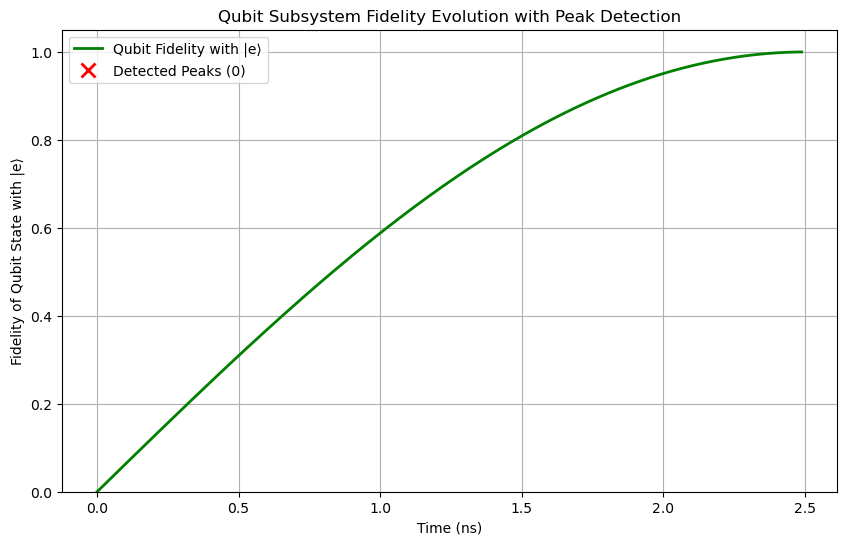

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from qutip import (
    tensor, qeye, destroy, basis, mesolve, sigmax, sigmay, sigmaz, sigmam, Bloch,
    fidelity
)
from scipy.signal import find_peaks
import time

# Use the older parameter name for compatibility with older matplotlib versions
try:
    plt.rcParams['animation.html_size_limit'] = 50.0
except KeyError:
    # Fallback for older versions
    plt.rcParams['animation.embed_limit'] = 50.0


# === Animation Class (Unchanged) ===
class BlochAnimation:
    def __init__(self, result, title, fig, axes):
        self.result, self.fig, self.axes = result, fig, axes
        self.sphere = Bloch(axes=axes); self.sphere.vector_color = ["r"]
        self.sphere.zlabel = [r'$|g\rangle$', r'$|e\rangle$']; self.sphere.title = title
    def update(self, n):
        self.sphere.clear()
        vec = [self.result.expect[0][n], self.result.expect[1][n], self.result.expect[2][n]]
        self.sphere.add_vectors(vec)
        self.sphere.add_points([self.result.expect[0][:n+1], self.result.expect[1][:n+1], self.result.expect[2][:n+1]], meth="l")
        self.sphere.make_sphere()
        return self.axes.artists


def plot_qubit_fidelity_and_animate_with_peaks():
    """
    This version finds and annotates the peaks in the qubit fidelity plot
    and runs the simulation long enough to generate multiple peaks.
    """
    print("--- Starting Qubit Fidelity Analysis with Peak Detection ---")
    
    # --- 1. SETUP: Parameters and Operators (Unchanged) ---
    wa = 5.0 * 2 * np.pi
    wc = 5.0 * 2 * np.pi
    g  = 0.1 * 2 * np.pi
    N  = 10
    Omega_d = 0.02 * 2 * np.pi
    omega_drive = wa
    gamma = 1.0 / 100e3
    kappa = 1.0 / 100

    a = tensor(destroy(N), qeye(2))
    sm = tensor(qeye(N), sigmam())
    H0 = wc * a.dag() * a + wa * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())
    H_drive_op = tensor(qeye(N), sigmax())
    drive_coeff = lambda t, args: 0.5 * Omega_d * np.cos(omega_drive * t)
    H_total = [H0, [H_drive_op, drive_coeff]]
    c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]
    rho_ground = tensor(basis(N, 0), basis(2, 0)) * tensor(basis(N, 0), basis(2, 0)).dag()

    # --- 2. CALIBRATION: Find the precise gate time (Unchanged) ---
    print("\nPart A: Calibrating to find optimal π-pulse time...")
    theoretical_gate_time = np.pi / Omega_d
    calibration_duration = theoretical_gate_time * 1.2
    tlist_calib = np.linspace(0, calibration_duration, 501)
    sz_operator = tensor(qeye(N), sigmaz())
    solver_options_calib = {"method": "bdf", "nsteps": 50000}
    
    result_calib = mesolve(H_total, rho_ground, tlist_calib, c_ops, [sz_operator], options=solver_options_calib)
    stop_index = np.argmin(result_calib.expect[0])
    precise_gate_time = tlist_calib[stop_index]
    print(f"--> Optimal π-pulse (X-gate) time found: {precise_gate_time:.6f} ns")

    # --- 3. MAIN SIMULATION ---
    simulation_duration = precise_gate_time * 3.5
    num_points = int(201 * 3.5) 
    print(f"\nPart B: Running high-resolution simulation for {simulation_duration:.2f} ns to observe oscillations...")
    
    tlist_main = np.linspace(0, 2.4889, 201)
    observables = [tensor(qeye(N), sigmax()), tensor(qeye(N), sigmay()), sz_operator]
    solver_options_main = {"method": "bdf", "nsteps": 50000, "store_states": True}
    
    result_main = mesolve(H_total, rho_ground, tlist_main, c_ops, observables, options=solver_options_main)
    print("Main simulation complete.")
    
    # --- 4. FIDELITY ANALYSIS AND PLOTTING WITH PEAK DETECTION ---
    print("\nPart C: Calculating QUBIT fidelity and finding peaks...")
    
    qubit_target_rho = basis(2, 1) * basis(2, 1).dag()
    fidelity_over_time = [
        fidelity(qubit_target_rho, state.ptrace(1)) for state in result_main.states
    ]

    # Find the peaks in the fidelity data
    peak_indices, _ = find_peaks(
        fidelity_over_time,
        height=0.5,
        prominence=0.2
    )
    
    # ***** THE FIX IS HERE *****
    # We must convert result_main.times to a numpy array before indexing with peak_indices.
    peak_times = np.array(result_main.times)[peak_indices]
    
    # This line was already correct, as it also converts the list to an array first.
    peak_fidelities = np.array(fidelity_over_time)[peak_indices]
    
    print(f"--> Found {len(peak_indices)} significant peaks:")
    for i in range(len(peak_times)):
        print(f"  - Peak {i+1}: Time = {peak_times[i]:.4f} ns, Fidelity = {peak_fidelities[i]:.4f}")

    # Plot the fidelity vs. time with peaks annotated
    fig_f, ax_f = plt.subplots(figsize=(10, 6))
    ax_f.plot(result_main.times, fidelity_over_time, lw=2, color='green', label='Qubit Fidelity with |e⟩')
    ax_f.plot(peak_times, peak_fidelities, "x", color='red', markersize=10, mew=2, label=f'Detected Peaks ({len(peak_indices)})')

    for i in range(len(peak_times)):
        ax_f.annotate(f'{peak_fidelities[i]:.3f}',
                      xy=(peak_times[i], peak_fidelities[i]),
                      xytext=(peak_times[i], peak_fidelities[i] + 0.05),
                      ha='center',
                      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    ax_f.set_xlabel("Time (ns)")
    ax_f.set_ylabel("Fidelity of Qubit State with |e⟩")
    ax_f.set_title("Qubit Subsystem Fidelity Evolution with Peak Detection")
    ax_f.set_ylim(0, 1.05)
    ax_f.grid(True)
    ax_f.legend()
    plt.show()


# Run the full analysis
if __name__ == '__main__':
    plot_qubit_fidelity_and_animate_with_peaks()

## Y Gate

--- Starting Y-Gate Fidelity Analysis with Peak Detection ---

Part A: Calibrating to find optimal π-pulse time...


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


--> Optimal π-pulse (Y-gate) time found: 12.480000 ns

Part B: Running high-resolution simulation for 43.68 ns to observe oscillations...
Main simulation complete.

Part C: Calculating QUBIT fidelity and finding peaks...
--> Found 9 significant peaks:
  - Peak 1: Time = 2.4889 ns, Fidelity = 0.9995
  - Peak 2: Time = 7.5289 ns, Fidelity = 0.9988
  - Peak 3: Time = 12.5067 ns, Fidelity = 0.9999
  - Peak 4: Time = 17.4844 ns, Fidelity = 0.9989
  - Peak 5: Time = 22.5244 ns, Fidelity = 0.9996
  - Peak 6: Time = 27.5022 ns, Fidelity = 0.9993
  - Peak 7: Time = 32.4800 ns, Fidelity = 0.9991
  - Peak 8: Time = 37.5200 ns, Fidelity = 0.9997
  - Peak 9: Time = 42.4978 ns, Fidelity = 0.9991


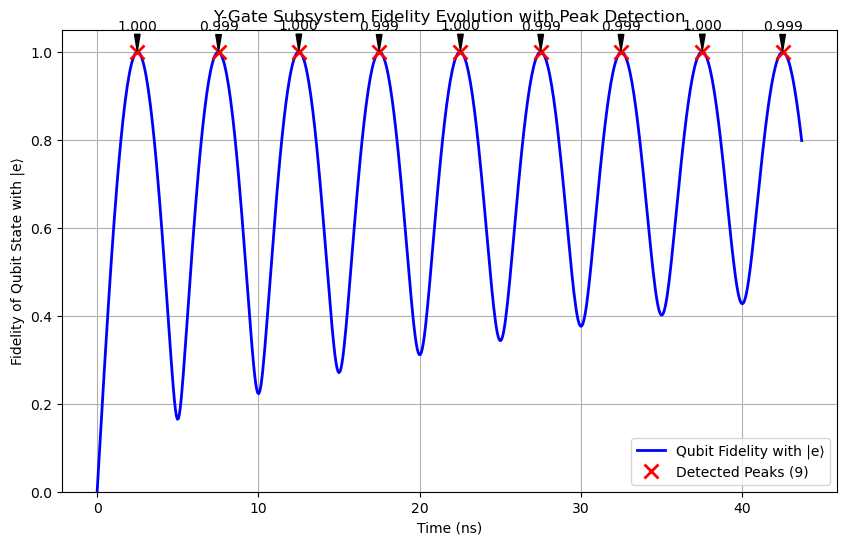

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from qutip import (
    tensor, qeye, destroy, basis, mesolve, sigmax, sigmay, sigmaz, sigmam, Bloch,
    fidelity
)
from scipy.signal import find_peaks
import time

# Use the older parameter name for compatibility with older matplotlib versions
try:
    plt.rcParams['animation.html_size_limit'] = 50.0
except KeyError:
    # Fallback for older versions
    plt.rcParams['animation.embed_limit'] = 50.0


# === Animation Class (Unchanged) ===
class BlochAnimation:
    def __init__(self, result, title, fig, axes):
        self.result, self.fig, self.axes = result, fig, axes
        self.sphere = Bloch(axes=axes); self.sphere.vector_color = ["r"]
        self.sphere.zlabel = [r'$|g\rangle$', r'$|e\rangle$']; self.sphere.title = title
    def update(self, n):
        self.sphere.clear()
        vec = [self.result.expect[0][n], self.result.expect[1][n], self.result.expect[2][n]]
        self.sphere.add_vectors(vec)
        self.sphere.add_points([self.result.expect[0][:n+1], self.result.expect[1][:n+1], self.result.expect[2][:n+1]], meth="l")
        self.sphere.make_sphere()
        return self.axes.artists


def plot_Y_gate_fidelity_and_animate():
    """
    This version performs the full analysis for a Y-GATE, including finding and
    annotating the peaks in the qubit fidelity plot.
    """
    print("--- Starting Y-Gate Fidelity Analysis with Peak Detection ---")
    
    # --- 1. SETUP: Parameters and Operators ---
    wa = 5.0 * 2 * np.pi
    wc = 5.0 * 2 * np.pi
    g  = 0.1 * 2 * np.pi
    N  = 10
    Omega_d = 0.02 * 2 * np.pi
    omega_drive = wa
    gamma = 1.0 / 100e3
    kappa = 1.0 / 100

    a = tensor(destroy(N), qeye(2))
    sm = tensor(qeye(N), sigmam())
    H0 = wc * a.dag() * a + wa * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())
    
    # ***** THE CRUCIAL CHANGE IS HERE: Use sigmay() for a Y-gate *****
    H_drive_op = tensor(qeye(N), sigmay())
    
    drive_coeff = lambda t, args: 0.5 * Omega_d * np.cos(omega_drive * t) # Drive form is the same
    H_total = [H0, [H_drive_op, drive_coeff]]
    c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]
    rho_ground = tensor(basis(N, 0), basis(2, 0)) * tensor(basis(N, 0), basis(2, 0)).dag()

    # --- 2. CALIBRATION: Find the precise gate time ---
    # The method is the same, as a Y-gate also takes |g> -> |e>
    print("\nPart A: Calibrating to find optimal π-pulse time...")
    theoretical_gate_time = np.pi / Omega_d
    calibration_duration = theoretical_gate_time * 1.2
    tlist_calib = np.linspace(0, calibration_duration, 501)
    sz_operator = tensor(qeye(N), sigmaz())
    solver_options_calib = {"method": "bdf", "nsteps": 50000}
    
    result_calib = mesolve(H_total, rho_ground, tlist_calib, c_ops, [sz_operator], options=solver_options_calib)
    stop_index = np.argmin(result_calib.expect[0])
    precise_gate_time = tlist_calib[stop_index]
    print(f"--> Optimal π-pulse (Y-gate) time found: {precise_gate_time:.6f} ns")

    # --- 3. MAIN SIMULATION ---
    simulation_duration = precise_gate_time * 3.5
    num_points = int(201 * 3.5) 
    print(f"\nPart B: Running high-resolution simulation for {simulation_duration:.2f} ns to observe oscillations...")
    
    tlist_main = np.linspace(0, simulation_duration, num_points)
    observables = [tensor(qeye(N), sigmax()), tensor(qeye(N), sigmay()), sz_operator]
    solver_options_main = {"method": "bdf", "nsteps": 50000, "store_states": True}
    
    result_main = mesolve(H_total, rho_ground, tlist_main, c_ops, observables, options=solver_options_main)
    print("Main simulation complete.")
    
    # --- 4. FIDELITY ANALYSIS AND PLOTTING WITH PEAK DETECTION ---
    print("\nPart C: Calculating QUBIT fidelity and finding peaks...")
    
    # The target state |e> is the same for a Y-gate starting from |g>
    qubit_target_rho = basis(2, 1) * basis(2, 1).dag()
    fidelity_over_time = [
        fidelity(qubit_target_rho, state.ptrace(1)) for state in result_main.states
    ]

    # Find the peaks in the fidelity data
    peak_indices, _ = find_peaks(
        fidelity_over_time,
        height=0.5,
        prominence=0.2
    )
    
    peak_times = np.array(result_main.times)[peak_indices]
    peak_fidelities = np.array(fidelity_over_time)[peak_indices]
    
    print(f"--> Found {len(peak_indices)} significant peaks:")
    for i in range(len(peak_times)):
        print(f"  - Peak {i+1}: Time = {peak_times[i]:.4f} ns, Fidelity = {peak_fidelities[i]:.4f}")

    # Plot the fidelity vs. time with peaks annotated
    fig_f, ax_f = plt.subplots(figsize=(10, 6))
    ax_f.plot(result_main.times, fidelity_over_time, lw=2, color='blue', label='Qubit Fidelity with |e⟩')
    ax_f.plot(peak_times, peak_fidelities, "x", color='red', markersize=10, mew=2, label=f'Detected Peaks ({len(peak_indices)})')

    for i in range(len(peak_times)):
        ax_f.annotate(f'{peak_fidelities[i]:.3f}',
                      xy=(peak_times[i], peak_fidelities[i]),
                      xytext=(peak_times[i], peak_fidelities[i] + 0.05),
                      ha='center',
                      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    ax_f.set_xlabel("Time (ns)")
    ax_f.set_ylabel("Fidelity of Qubit State with |e⟩")
    ax_f.set_title("Y-Gate Subsystem Fidelity Evolution with Peak Detection")
    ax_f.set_ylim(0, 1.05)
    ax_f.grid(True)
    ax_f.legend()
    plt.show()



# Run the full analysis
if __name__ == '__main__':
    plot_Y_gate_fidelity_and_animate()

--- Starting Y-Gate Fidelity Analysis with Peak Detection ---

Part A: Calibrating to find optimal π-pulse time...
--> Optimal π-pulse (Y-gate) time found: 12.480000 ns

Part B: Running high-resolution simulation for 43.68 ns to observe oscillations...
Main simulation complete.

Part C: Calculating QUBIT fidelity and finding peaks...
--> Found 0 significant peaks:


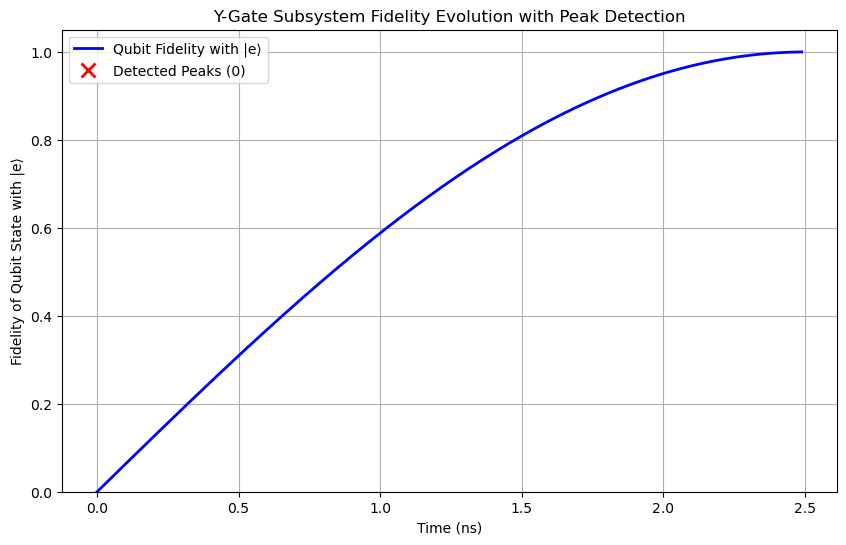

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from qutip import (
    tensor, qeye, destroy, basis, mesolve, sigmax, sigmay, sigmaz, sigmam, Bloch,
    fidelity
)
from scipy.signal import find_peaks
import time

# Use the older parameter name for compatibility with older matplotlib versions
try:
    plt.rcParams['animation.html_size_limit'] = 50.0
except KeyError:
    # Fallback for older versions
    plt.rcParams['animation.embed_limit'] = 50.0


# === Animation Class (Unchanged) ===
class BlochAnimation:
    def __init__(self, result, title, fig, axes):
        self.result, self.fig, self.axes = result, fig, axes
        self.sphere = Bloch(axes=axes); self.sphere.vector_color = ["r"]
        self.sphere.zlabel = [r'$|g\rangle$', r'$|e\rangle$']; self.sphere.title = title
    def update(self, n):
        self.sphere.clear()
        vec = [self.result.expect[0][n], self.result.expect[1][n], self.result.expect[2][n]]
        self.sphere.add_vectors(vec)
        self.sphere.add_points([self.result.expect[0][:n+1], self.result.expect[1][:n+1], self.result.expect[2][:n+1]], meth="l")
        self.sphere.make_sphere()
        return self.axes.artists


def plot_Y_gate_fidelity_and_animate():
    """
    This version performs the full analysis for a Y-GATE, including finding and
    annotating the peaks in the qubit fidelity plot.
    """
    print("--- Starting Y-Gate Fidelity Analysis with Peak Detection ---")
    
    # --- 1. SETUP: Parameters and Operators ---
    wa = 5.0 * 2 * np.pi
    wc = 5.0 * 2 * np.pi
    g  = 0.1 * 2 * np.pi
    N  = 10
    Omega_d = 0.02 * 2 * np.pi
    omega_drive = wa
    gamma = 1.0 / 100e3
    kappa = 1.0 / 100

    a = tensor(destroy(N), qeye(2))
    sm = tensor(qeye(N), sigmam())
    H0 = wc * a.dag() * a + wa * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())
    
    # ***** THE CRUCIAL CHANGE IS HERE: Use sigmay() for a Y-gate *****
    H_drive_op = tensor(qeye(N), sigmay())
    
    drive_coeff = lambda t, args: 0.5 * Omega_d * np.cos(omega_drive * t) # Drive form is the same
    H_total = [H0, [H_drive_op, drive_coeff]]
    c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]
    rho_ground = tensor(basis(N, 0), basis(2, 0)) * tensor(basis(N, 0), basis(2, 0)).dag()

    # --- 2. CALIBRATION: Find the precise gate time ---
    # The method is the same, as a Y-gate also takes |g> -> |e>
    print("\nPart A: Calibrating to find optimal π-pulse time...")
    theoretical_gate_time = np.pi / Omega_d
    calibration_duration = theoretical_gate_time * 1.2
    tlist_calib = np.linspace(0, calibration_duration, 501)
    sz_operator = tensor(qeye(N), sigmaz())
    solver_options_calib = {"method": "bdf", "nsteps": 50000}
    
    result_calib = mesolve(H_total, rho_ground, tlist_calib, c_ops, [sz_operator], options=solver_options_calib)
    stop_index = np.argmin(result_calib.expect[0])
    precise_gate_time = tlist_calib[stop_index]
    print(f"--> Optimal π-pulse (Y-gate) time found: {precise_gate_time:.6f} ns")

    # --- 3. MAIN SIMULATION ---
    simulation_duration = precise_gate_time * 3.5
    num_points = int(201 * 3.5) 
    print(f"\nPart B: Running high-resolution simulation for {simulation_duration:.2f} ns to observe oscillations...")
    
    tlist_main = np.linspace(0, 2.4889, 201)
    observables = [tensor(qeye(N), sigmax()), tensor(qeye(N), sigmay()), sz_operator]
    solver_options_main = {"method": "bdf", "nsteps": 50000, "store_states": True}
    
    result_main = mesolve(H_total, rho_ground, tlist_main, c_ops, observables, options=solver_options_main)
    print("Main simulation complete.")
    
    # --- 4. FIDELITY ANALYSIS AND PLOTTING WITH PEAK DETECTION ---
    print("\nPart C: Calculating QUBIT fidelity and finding peaks...")
    
    # The target state |e> is the same for a Y-gate starting from |g>
    qubit_target_rho = basis(2, 1) * basis(2, 1).dag()
    fidelity_over_time = [
        fidelity(qubit_target_rho, state.ptrace(1)) for state in result_main.states
    ]

    # Find the peaks in the fidelity data
    peak_indices, _ = find_peaks(
        fidelity_over_time,
        height=0.5,
        prominence=0.2
    )
    
    peak_times = np.array(result_main.times)[peak_indices]
    peak_fidelities = np.array(fidelity_over_time)[peak_indices]
    
    print(f"--> Found {len(peak_indices)} significant peaks:")
    for i in range(len(peak_times)):
        print(f"  - Peak {i+1}: Time = {peak_times[i]:.4f} ns, Fidelity = {peak_fidelities[i]:.4f}")

    # Plot the fidelity vs. time with peaks annotated
    fig_f, ax_f = plt.subplots(figsize=(10, 6))
    ax_f.plot(result_main.times, fidelity_over_time, lw=2, color='blue', label='Qubit Fidelity with |e⟩')
    ax_f.plot(peak_times, peak_fidelities, "x", color='red', markersize=10, mew=2, label=f'Detected Peaks ({len(peak_indices)})')

    for i in range(len(peak_times)):
        ax_f.annotate(f'{peak_fidelities[i]:.3f}',
                      xy=(peak_times[i], peak_fidelities[i]),
                      xytext=(peak_times[i], peak_fidelities[i] + 0.05),
                      ha='center',
                      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    ax_f.set_xlabel("Time (ns)")
    ax_f.set_ylabel("Fidelity of Qubit State with |e⟩")
    ax_f.set_title("Y-Gate Subsystem Fidelity Evolution with Peak Detection")
    ax_f.set_ylim(0, 1.05)
    ax_f.grid(True)
    ax_f.legend()
    plt.show()

   

# Run the full analysis
if __name__ == '__main__':
    plot_Y_gate_fidelity_and_animate()

## Z Gate

--- Starting Z-Gate Fidelity Analysis with Peak Detection ---

Part A: Calculating the theoretical Z-gate time...
--> Theoretical gate time for a π-rotation around Z: 1.000000 ns

Part B: Running high-resolution simulation for 3.50 ns to observe Z-rotations...
Main simulation complete.

Part C: Calculating QUBIT fidelity and finding peaks...
--> Found 13 significant peaks:
  - Peak 1: Time = 0.0997 ns, Fidelity = 0.9995
  - Peak 2: Time = 0.2991 ns, Fidelity = 0.9955
  - Peak 3: Time = 0.4986 ns, Fidelity = 0.9876
  - Peak 4: Time = 0.6980 ns, Fidelity = 0.9758
  - Peak 5: Time = 0.8974 ns, Fidelity = 0.9601
  - Peak 6: Time = 1.0969 ns, Fidelity = 0.9407
  - Peak 7: Time = 1.3013 ns, Fidelity = 0.9179
  - Peak 8: Time = 1.5007 ns, Fidelity = 0.8916
  - Peak 9: Time = 1.7001 ns, Fidelity = 0.8617
  - Peak 10: Time = 1.8996 ns, Fidelity = 0.8285
  - Peak 11: Time = 3.0014 ns, Fidelity = 0.8058
  - Peak 12: Time = 3.2009 ns, Fidelity = 0.8408
  - Peak 13: Time = 3.4003 ns, Fidelity = 0.8

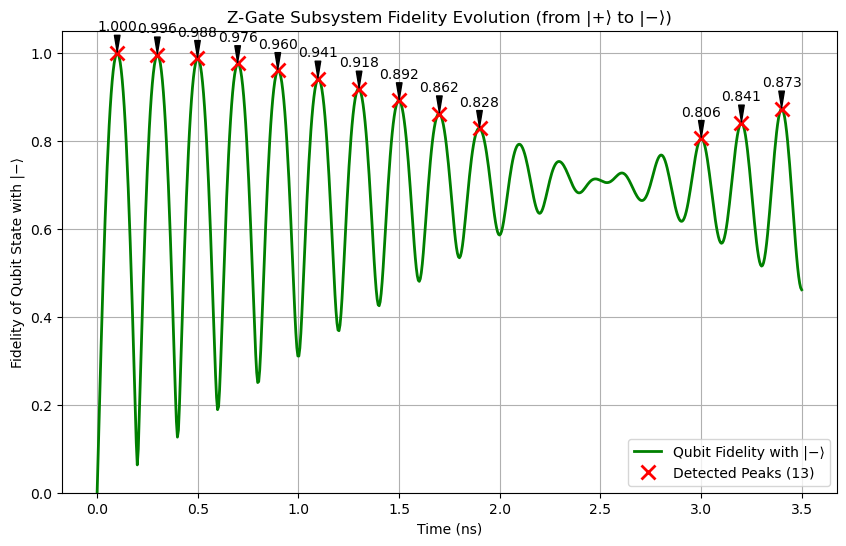

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from qutip import (
    tensor, qeye, destroy, basis, mesolve, sigmax, sigmay, sigmaz, sigmam, Bloch,
    fidelity
)
from scipy.signal import find_peaks
import time

# Use the older parameter name for compatibility with older matplotlib versions
try:
    plt.rcParams['animation.html_size_limit'] = 50.0
except KeyError:
    # Fallback for older versions
    plt.rcParams['animation.embed_limit'] = 50.0


# === Animation Class (Unchanged) ===



class BlochAnimation:
    def __init__(self, result, title, fig, axes):
        self.result, self.fig, self.axes = result, fig, axes
        self.sphere = Bloch(axes=axes); self.sphere.vector_color = ["r"]
        self.sphere.zlabel = [r'$|g\rangle$', r'$|e\rangle$']; self.sphere.title = title
    def update(self, n):
        self.sphere.clear()
        vec = [self.result.expect[0][n], self.result.expect[1][n], self.result.expect[2][n]]
        self.sphere.add_vectors(vec)
        self.sphere.add_points([self.result.expect[0][:n+1], self.result.expect[1][:n+1], self.result.expect[2][:n+1]], meth="l")
        self.sphere.make_sphere()
        return self.axes.artists


def plot_Z_gate_fidelity_and_animate():
    """
    This version performs the full analysis for a Z-GATE, including finding and
    annotating the peaks in the qubit fidelity plot.
    """
    print("--- Starting Z-Gate Fidelity Analysis with Peak Detection ---")
    
    # --- 1. SETUP: Parameters and Operators ---
    # System parameters (Jaynes-Cummings model) remain the same
    wa = 5.0 * 2 * np.pi
    wc = 5.0 * 2 * np.pi
    g  = 0.1 * 2 * np.pi
    N  = 10 # Truncation of the cavity Fock space
    
    # ***** CHANGE 1: Define the drive strength for the Z-pulse *****
    # This is now the amplitude of our Z-pulse, which detunes the qubit.
    Omega_d = 0.5 * 2 * np.pi
    omega_drive = wa
    
    gamma = 1.0 / 100e3 # Qubit decay
    kappa = 1.0 / 100   # Cavity decay

    # System operators are defined similarly
    a = tensor(destroy(N), qeye(2))
    sm = tensor(qeye(N), sigmam())
    H0 = wc * a.dag() * a + wa * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())
    
    # ***** CHANGE 2: The drive operator is now sigmaz() for a Z-gate *****
    H_drive_op = tensor(qeye(N), sigmaz())
    
    # A Z-pulse is a static energy shift, so the drive coefficient is constant
    drive_coeff = lambda t, args: 0.5 * Omega_d * np.cos(omega_drive * t)  # The 0.5 is a convention from H = 0.5*Omega*sigma
    H_total = [H0, [H_drive_op, drive_coeff]]
    c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

    # ***** CHANGE 3: The initial state must be a superposition to see a Z-gate's effect *****
    # We start in the |+> state = (|g> + |e>)/sqrt(2)
    qubit_plus_state = (basis(2, 0) + basis(2, 1)).unit()
    rho_initial = tensor(basis(N, 0), qubit_plus_state) * tensor(basis(N, 0), qubit_plus_state).dag()

    # --- 2. GATE TIME CALCULATION ---
    # For a Z-gate, the goal is to accumulate a relative phase of pi.
    # The time evolution due to the drive is exp(-i * (Omega_d/2) * sigma_z * t).
    # We want (Omega_d/2) * t = pi/2 for a Z-gate (a pi-rotation around Z).
    # This gives t_gate = pi / Omega_d.
    print("\nPart A: Calculating the theoretical Z-gate time...")
    precise_gate_time = np.pi / Omega_d
    print(f"--> Theoretical gate time for a π-rotation around Z: {precise_gate_time:.6f} ns")

    # --- 3. MAIN SIMULATION ---
    simulation_duration = precise_gate_time * 3.5
    num_points = int(201 * 3.5) 
    print(f"\nPart B: Running high-resolution simulation for {simulation_duration:.2f} ns to observe Z-rotations...")
    
    tlist_main = np.linspace(0, simulation_duration, num_points)
    observables = [tensor(qeye(N), sigmax()), tensor(qeye(N), sigmay()), tensor(qeye(N), sigmaz())]
    solver_options_main = {"method": "bdf", "nsteps": 50000, "store_states": True}
    
    # Run the simulation starting from the |+> state
    result_main = mesolve(H_total, rho_initial, tlist_main, c_ops, observables, options=solver_options_main)
    print("Main simulation complete.")
    
    # --- 4. FIDELITY ANALYSIS AND PLOTTING WITH PEAK DETECTION ---
    print("\nPart C: Calculating QUBIT fidelity and finding peaks...")
    
    # ***** CHANGE 4: The target state for a Z-gate on |+> is the |-> state *****
    # |-> state = (|g> - |e>)/sqrt(2)
    qubit_minus_state = (basis(2, 0) - basis(2, 1)).unit()
    qubit_target_rho = qubit_minus_state * qubit_minus_state.dag()
    
    fidelity_over_time = [
        fidelity(qubit_target_rho, state.ptrace(1)) for state in result_main.states
    ]

    # Find the peaks in the fidelity data (logic is the same)
    peak_indices, _ = find_peaks(
        fidelity_over_time,
        height=0.5,
        prominence=0.2
    )
    
    peak_times = np.array(result_main.times)[peak_indices]
    peak_fidelities = np.array(fidelity_over_time)[peak_indices]
    
    print(f"--> Found {len(peak_indices)} significant peaks:")
    for i in range(len(peak_times)):
        print(f"  - Peak {i+1}: Time = {peak_times[i]:.4f} ns, Fidelity = {peak_fidelities[i]:.4f}")

    # Plot the fidelity vs. time with peaks annotated
    fig_f, ax_f = plt.subplots(figsize=(10, 6))
    ax_f.plot(result_main.times, fidelity_over_time, lw=2, color='green', label='Qubit Fidelity with |−⟩')
    ax_f.plot(peak_times, peak_fidelities, "x", color='red', markersize=10, mew=2, label=f'Detected Peaks ({len(peak_indices)})')

    for i in range(len(peak_times)):
        ax_f.annotate(f'{peak_fidelities[i]:.3f}',
                      xy=(peak_times[i], peak_fidelities[i]),
                      xytext=(peak_times[i], peak_fidelities[i] + 0.05),
                      ha='center',
                      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    ax_f.set_xlabel("Time (ns)")
    ax_f.set_ylabel("Fidelity of Qubit State with |−⟩")
    ax_f.set_title("Z-Gate Subsystem Fidelity Evolution (from |+⟩ to |−⟩)")
    ax_f.set_ylim(0, 1.05)
    ax_f.grid(True)
    ax_f.legend()
    plt.show()


# Run the full analysis
if __name__ == '__main__':
    plot_Z_gate_fidelity_and_animate()

--- Starting Z-Gate Fidelity Analysis with Peak Detection ---

Part A: Calculating the theoretical Z-gate time...
--> Theoretical gate time for a π-rotation around Z: 1.000000 ns

Part B: Running high-resolution simulation for 3.50 ns to observe Z-rotations...
Main simulation complete.

Part C: Calculating QUBIT fidelity and finding peaks...
--> Found 0 significant peaks:


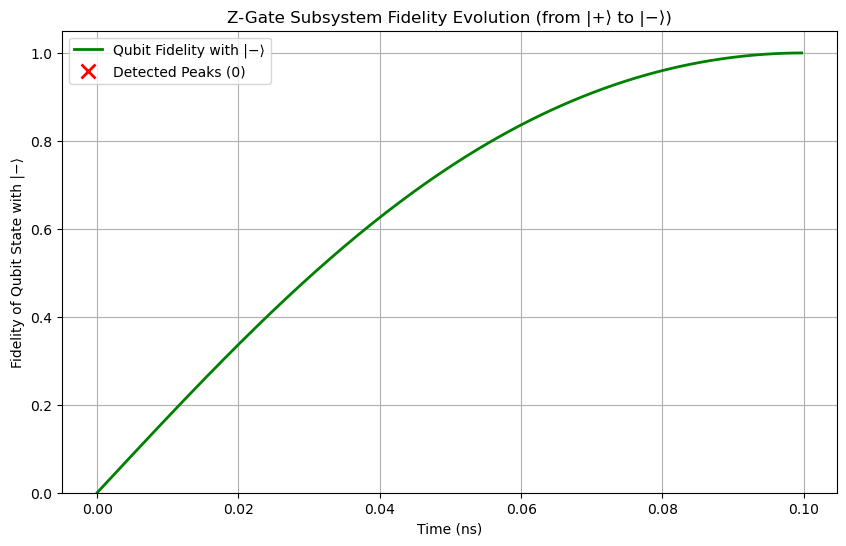

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from qutip import (
    tensor, qeye, destroy, basis, mesolve, sigmax, sigmay, sigmaz, sigmam, Bloch,
    fidelity
)
from scipy.signal import find_peaks
import time

# Use the older parameter name for compatibility with older matplotlib versions
try:
    plt.rcParams['animation.html_size_limit'] = 50.0
except KeyError:
    # Fallback for older versions
    plt.rcParams['animation.embed_limit'] = 50.0


# === Animation Class (Unchanged) ===
class BlochAnimation:
    def __init__(self, result, title, fig, axes):
        self.result, self.fig, self.axes = result, fig, axes
        self.sphere = Bloch(axes=axes); self.sphere.vector_color = ["r"]
        self.sphere.zlabel = [r'$|g\rangle$', r'$|e\rangle$']; self.sphere.title = title
    def update(self, n):
        self.sphere.clear()
        vec = [self.result.expect[0][n], self.result.expect[1][n], self.result.expect[2][n]]
        self.sphere.add_vectors(vec)
        self.sphere.add_points([self.result.expect[0][:n+1], self.result.expect[1][:n+1], self.result.expect[2][:n+1]], meth="l")
        self.sphere.make_sphere()
        return self.axes.artists


def plot_Z_gate_fidelity_and_animate():
    """
    This version performs the full analysis for a Z-GATE, including finding and
    annotating the peaks in the qubit fidelity plot.
    """
    print("--- Starting Z-Gate Fidelity Analysis with Peak Detection ---")
    
    # --- 1. SETUP: Parameters and Operators ---
    # System parameters (Jaynes-Cummings model) remain the same
    wa = 5.0 * 2 * np.pi
    wc = 5.0 * 2 * np.pi
    g  = 0.1 * 2 * np.pi
    N  = 10 # Truncation of the cavity Fock space
    
    # ***** CHANGE 1: Define the drive strength for the Z-pulse *****
    # This is now the amplitude of our Z-pulse, which detunes the qubit.
    Omega_d = 0.5 * 2 * np.pi
    omega_drive = wa
    
    gamma = 1.0 / 100e3 # Qubit decay
    kappa = 1.0 / 100   # Cavity decay

    # System operators are defined similarly
    a = tensor(destroy(N), qeye(2))
    sm = tensor(qeye(N), sigmam())
    H0 = wc * a.dag() * a + wa * sm.dag() * sm + g * (a.dag() * sm + a * sm.dag())
    
    # ***** CHANGE 2: The drive operator is now sigmaz() for a Z-gate *****
    H_drive_op = tensor(qeye(N), sigmaz())
    
    # A Z-pulse is a static energy shift, so the drive coefficient is constant
    drive_coeff = lambda t, args: 0.5 * Omega_d * np.cos(omega_drive * t) # The 0.5 is a convention from H = 0.5*Omega*sigma
    H_total = [H0, [H_drive_op, drive_coeff]]
    c_ops = [np.sqrt(kappa) * a, np.sqrt(gamma) * sm]

    # ***** CHANGE 3: The initial state must be a superposition to see a Z-gate's effect *****
    # We start in the |+> state = (|g> + |e>)/sqrt(2)
    qubit_plus_state = (basis(2, 0) + basis(2, 1)).unit()
    rho_initial = tensor(basis(N, 0), qubit_plus_state) * tensor(basis(N, 0), qubit_plus_state).dag()

    # --- 2. GATE TIME CALCULATION ---
    # For a Z-gate, the goal is to accumulate a relative phase of pi.
    # The time evolution due to the drive is exp(-i * (Omega_d/2) * sigma_z * t).
    # We want (Omega_d/2) * t = pi/2 for a Z-gate (a pi-rotation around Z).
    # This gives t_gate = pi / Omega_d.
    print("\nPart A: Calculating the theoretical Z-gate time...")
    precise_gate_time = np.pi / Omega_d
    print(f"--> Theoretical gate time for a π-rotation around Z: {precise_gate_time:.6f} ns")

    # --- 3. MAIN SIMULATION ---
    simulation_duration = precise_gate_time * 3.5
    num_points = int(201 * 3.5) 
    print(f"\nPart B: Running high-resolution simulation for {simulation_duration:.2f} ns to observe Z-rotations...")
    
    tlist_main = np.linspace(0, 0.0997, 201)
    observables = [tensor(qeye(N), sigmax()), tensor(qeye(N), sigmay()), tensor(qeye(N), sigmaz())]
    solver_options_main = {"method": "bdf", "nsteps": 50000, "store_states": True}
    
    # Run the simulation starting from the |+> state
    result_main = mesolve(H_total, rho_initial, tlist_main, c_ops, observables, options=solver_options_main)
    print("Main simulation complete.")
    
    # --- 4. FIDELITY ANALYSIS AND PLOTTING WITH PEAK DETECTION ---
    print("\nPart C: Calculating QUBIT fidelity and finding peaks...")
    
    # ***** CHANGE 4: The target state for a Z-gate on |+> is the |-> state *****
    # |-> state = (|g> - |e>)/sqrt(2)
    qubit_minus_state = (basis(2, 0) - basis(2, 1)).unit()
    qubit_target_rho = qubit_minus_state * qubit_minus_state.dag()
    
    fidelity_over_time = [
        fidelity(qubit_target_rho, state.ptrace(1)) for state in result_main.states
    ]

    # Find the peaks in the fidelity data (logic is the same)
    peak_indices, _ = find_peaks(
        fidelity_over_time,
        height=0.5,
        prominence=0.2
    )
    
    peak_times = np.array(result_main.times)[peak_indices]
    peak_fidelities = np.array(fidelity_over_time)[peak_indices]
    
    print(f"--> Found {len(peak_indices)} significant peaks:")
    for i in range(len(peak_times)):
        print(f"  - Peak {i+1}: Time = {peak_times[i]:.4f} ns, Fidelity = {peak_fidelities[i]:.4f}")

    # Plot the fidelity vs. time with peaks annotated
    fig_f, ax_f = plt.subplots(figsize=(10, 6))
    ax_f.plot(result_main.times, fidelity_over_time, lw=2, color='green', label='Qubit Fidelity with |−⟩')
    ax_f.plot(peak_times, peak_fidelities, "x", color='red', markersize=10, mew=2, label=f'Detected Peaks ({len(peak_indices)})')

    for i in range(len(peak_times)):
        ax_f.annotate(f'{peak_fidelities[i]:.3f}',
                      xy=(peak_times[i], peak_fidelities[i]),
                      xytext=(peak_times[i], peak_fidelities[i] + 0.05),
                      ha='center',
                      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    ax_f.set_xlabel("Time (ns)")
    ax_f.set_ylabel("Fidelity of Qubit State with |−⟩")
    ax_f.set_title("Z-Gate Subsystem Fidelity Evolution (from |+⟩ to |−⟩)")
    ax_f.set_ylim(0, 1.05)
    ax_f.grid(True)
    ax_f.legend()
    plt.show()

    
# Run the full analysis
if __name__ == '__main__':
    plot_Z_gate_fidelity_and_animate()

## Hadamard Gate

--- Hadamard Gate Fidelity Plot ---

Part A: Calibrating the IDEAL gate...

        IDEAL GATE PARAMETERS
  > Gate Time for Y(pi/2): 0.500000 ns
  > Expected Final Fidelity: 1.00000000

Part B: Generating fidelity plot...


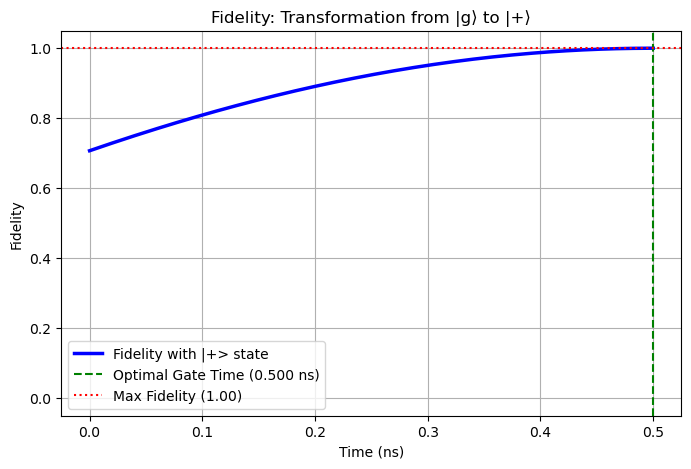

------------------------------------------------------------


In [45]:
import numpy as np
import matplotlib.pyplot as plt
# Animation-specific imports have been removed.
# IPython display helpers have been removed.
from qutip import (
    tensor, qeye, destroy, basis, mesolve, sigmam,
    fidelity, Options
)
# sigmax, sigmay, sigmaz, Bloch are no longer needed and have been removed.


def plot_hadamard_gate_fidelity():
    """
    This function calculates the state evolution for a Y(pi/2) pulse
    and plots the fidelity of the evolving state with respect to the
    target |+> state over time.
    """
    print("--- Hadamard Gate Fidelity Plot ---")

    # --- 1. SETUP: Parameters for an ideal Y(pi/2) pulse ---
    # These parameters are kept for context, but only Omega_d is used in the simple model.
    wa = 5.0 * 2 * np.pi
    wc = 6.0 * 2 * np.pi
    g  = 0.1 * 2 * np.pi
    N  = 10
    Omega_d = 0.5 * 2 * np.pi
    omega_drive = wa

    # The effective Hamiltonian in the rotating frame is just the drive term.
    # This ensures a "perfect" rotation for the fidelity calculation.
    H_simple = 0.5 * Omega_d * sigmam().dag() - 0.5 * Omega_d * sigmam() # This is 0.5 * Omega_d * i * sigmay() up to a phase
    # A cleaner way is to just use sigmay
    from qutip import sigmay
    H_simple = 0.5 * Omega_d * sigmay()

    # The qubit starts in the ground state |g>
    rho_initial_simple = basis(2, 0) * basis(2, 0).dag()

    print("\nPart A: Calibrating the IDEAL gate...")

    # For a perfect Y(pi/2) rotation, the required evolution time is precise.
    # The rotation angle θ = Ω*t. We want θ = π/2.
    # Therefore, t = (π/2) / Ω
    optimal_time = (np.pi / 2) / Omega_d
    max_fidelity = 1.0

    print("\n" + "="*40)
    print("        IDEAL GATE PARAMETERS")
    print("="*40)
    print(f"  > Gate Time for Y(pi/2): {optimal_time:.6f} ns")
    print(f"  > Expected Final Fidelity: {max_fidelity:.8f}")
    print("="*40 + "\n")

    # --- 2. SIMULATE AND PLOT FIDELITY ---
    print("Part B: Generating fidelity plot...")

    # We will simulate for the exact duration of the gate.
    sim_tlist = np.linspace(0, optimal_time, 201) # Increased points for a smoother curve

    # We need to explicitly tell mesolve to store the states at each time step
    # so we can calculate the fidelity.
    qutip_options = Options(store_states=True)

    # Run the simulation. Note that 'e_ops' (expectation operators) are not needed
    # since we are not animating the Bloch sphere.
    result = mesolve(
        H_simple, rho_initial_simple, sim_tlist, c_ops=[], e_ops=[], options=qutip_options
    )

    # --- This is the main block for the fidelity plot ---
    # Define the target state |+> = (|g> + |e>) / sqrt(2)
    plus_state = (basis(2, 0) + basis(2, 1)).unit()
    rho_target = plus_state * plus_state.dag()

    # Calculate fidelity at each time step using the states saved from the simulation.
    fidelities = [fidelity(state, rho_target) for state in result.states]

    # Create and display the plot
    plt.figure(figsize=(8, 5))
    plt.plot(sim_tlist, fidelities, 'b-', lw=2.5, label='Fidelity with |+> state')
    plt.axvline(x=optimal_time, color='g', linestyle='--', label=f'Optimal Gate Time ({optimal_time:.3f} ns)')
    plt.axhline(y=max_fidelity, color='r', linestyle=':', label=f'Max Fidelity ({max_fidelity:.2f})')
    plt.xlabel("Time (ns)")
    plt.ylabel("Fidelity")
    plt.title("Fidelity: Transformation from |g⟩ to |+⟩")
    plt.legend()
    plt.grid(True)
    plt.ylim(-0.05, 1.05)
    plt.show() # This will display the plot
    print("-" * 60)


if __name__ == '__main__':
    plot_hadamard_gate_fidelity()